# How Comparable Are AI-Generated Mathematics Items to Those Written by Pedagogical Specialists?

## Reproducing the tables in the paper

This notebook reproduces, from the anonymized public pilot data in `../data/`, every table cited in the final paper: **Table 1, Table 2a, Table 2b, Table 3, Table 4**, and the appendix tables **Table A1, B1, C1, D1, E1**.

All student identifiers here are anonymized (`student_id`, e.g. `EST0001`) and schools are relabeled (`school_id`, `Colegio_1`...`Colegio_6`). No names, no real school names, no raw document/ID codes are present in this data. All data files, column names, categorical values, item text, and distractor rationale notes have been translated to English (see `data/CODEBOOK.md` for full details and for the two exceptions noted there).

Run the cells top to bottom. The semantic-similarity section (Table D1) needs `sentence-transformers` and `bert-score`; the reliability section needs `factor_analyzer`. Install cells are included where needed.

**Note on Table D1:** it is computed on the English-translated item text (translated from the original Spanish pilot instrument for this public, English-language repository). Values may differ slightly from the Spanish-text results reported in the paper, since translation changes the exact wording that the embedding models see.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")
OUTPUT_TABLES = Path("outputs/tables")
OUTPUT_FIGURES = Path("outputs/figures")
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 1. Load the pilot data

The data folder contains five files, all anonymized and in English:
- `questionnaire_anonymized.csv`: student questionnaire (sex, background), keyed by `student_id`. Question codes `p1`...`p13h` follow the original instrument; see `data/CODEBOOK.md` for what each code means.
- `test_1/2/3_anonymized.csv`: item-level responses for the three test forms, keyed by `student_id`.
- `item_bank_expert_review.xlsx`: the item bank plus the specialist/teacher technical review.

Column names for item responses follow the original instrument's global item numbering (e.g. `item_correct_257`); below we remap them to `item_correct_1`...`item_correct_30` per test, keyed on `student_id`.

In [2]:
questionnaire = pd.read_csv(DATA_DIR / "questionnaire_anonymized.csv", dtype={"student_id": str})
questionnaire = questionnaire[["student_id", "school_id", "sex"]].copy()

print("Questionnaire:", questionnaire.shape)
display(questionnaire.head())

Questionnaire: (207, 3)


,student_id,school_id,sex
0,EST0068,Colegio_3,Female
1,EST0080,Colegio_3,Male
2,EST0069,Colegio_3,Female
3,EST0078,Colegio_3,Male
4,EST0064,Colegio_3,Female


## 2. Item metadata (Annex 9) and test-form reshape

`build_item_metadata()` is the fixed item-level key: for each test (1-3) and item number (1-30), it records the keyed correct answer, the mathematical content, the item's origin (`AI` = AI-generated, `Bank` = item bank), and the intended cognitive demand. This comes from the study's design documentation, not from student data, so it carries no PII.

In [3]:
def build_item_metadata() -> pd.DataFrame:
    rows = []

    test_1 = [
        (1, "b", "Addition and subtraction operations", "Bank", "Low"),
        (2, "a", "Addition and subtraction operations", "AI", "Low"),
        (3, "d", "Multiplication operations", "Bank", "Low"),
        (4, "a", "Addition and subtraction operations", "AI", "Low"),
        (5, "a", "Decimal number system", "Bank", "Low"),
        (6, "a", "Multiplication operations", "AI", "Low"),
        (7, "b", "Division operations", "Bank", "Low"),
        (8, "b", "Addition and subtraction operations", "AI", "Low"),
        (9, "b", "Addition and subtraction operations", "Bank", "Low"),
        (10, "a", "Multiplication operations", "AI", "Low"),
        (11, "b", "Multiplication operations", "Bank", "Medium"),
        (12, "b", "Multiplicative problems", "AI", "Medium"),
        (13, "b", "Multiplicative problems", "Bank", "Medium"),
        (14, "b", "Multiplicative problems", "AI", "Medium"),
        (15, "b", "Multiplicative problems", "Bank", "Medium"),
        (16, "a", "Fractions, equivalent fractions", "AI", "Medium"),
        (17, "c", "Multiplicative problems", "Bank", "Medium"),
        (18, "b", "Multiplicative problems", "AI", "Medium"),
        (19, "a", "Fractions, equivalent fractions", "Bank", "Medium"),
        (20, "b", "Additive problems", "AI", "Medium"),
        (21, "b", "Multiplicative problems", "Bank", "High"),
        (22, "b", "Multiplicative problems", "AI", "High"),
        (23, "d", "Multiplicative problems", "Bank", "High"),
        (24, "a", "Multiplicative problems", "AI", "High"),
        (25, "b", "Fractions, equivalent fractions", "Bank", "High"),
        (26, "b", "Multiplicative problems", "AI", "High"),
        (27, "b", "Additive problems", "Bank", "High"),
        (28, "b", "Multiplicative problems", "AI", "High"),
        (29, "c", "Additive problems", "Bank", "High"),
        (30, "b", "Multiplicative problems", "AI", "High"),
    ]

    test_2 = [
        (1, "c", "Division operations", "Bank", "Low"),
        (2, "b", "Addition and subtraction operations", "AI", "Low"),
        (3, "a", "Addition and subtraction operations", "Bank", "Low"),
        (4, "a", "Fractions, equivalent fractions", "AI", "Low"),
        (5, "c", "Addition and subtraction operations", "Bank", "Low"),
        (6, "a", "Fractions, equivalent fractions", "AI", "Low"),
        (7, "b", "Addition and subtraction operations", "Bank", "Low"),
        (8, "b", "Fractions, equivalent fractions", "AI", "Low"),
        (9, "b", "Decimal number system", "Bank", "Low"),
        (10, "a", "Fractions, equivalent fractions", "AI", "Low"),
        (11, "a", "Decimal number system", "Bank", "Medium"),
        (12, "b", "Multiplicative problems", "AI", "Medium"),
        (13, "c", "Multiplicative problems", "Bank", "Medium"),
        (14, "b", "Multiplicative problems", "AI", "Medium"),
        (15, "c", "Multiplicative problems", "Bank", "Medium"),
        (16, "c", "Multiplicative problems", "AI", "Medium"),
        (17, "d", "Multiplicative problems", "Bank", "Medium"),
        (18, "a", "Multiplicative problems", "AI", "Medium"),
        (19, "a", "Fractions, equivalent fractions", "Bank", "Medium"),
        (20, "c", "Additive problems", "AI", "Medium"),
        (21, "c", "Decimal number system", "Bank", "High"),
        (22, "a", "Multiplicative problems", "AI", "High"),
        (23, "a", "Multiplicative problems", "Bank", "High"),
        (24, "b", "Additive problems", "AI", "High"),
        (25, "d", "Multiplicative problems", "Bank", "High"),
        (26, "b", "Fractions, equivalent fractions", "AI", "High"),
        (27, "c", "Multiplicative problems", "Bank", "High"),
        (28, "b", "Multiplicative problems", "AI", "High"),
        (29, "a", "Multiplicative problems", "Bank", "High"),
        (30, "b", "Multiplicative problems", "AI", "High"),
    ]

    test_3 = [
        (1, "c", "Addition and subtraction operations", "Bank", "Low"),
        (2, "a", "Addition and subtraction operations", "AI", "Low"),
        (3, "b", "Decimal number system", "Bank", "Low"),
        (4, "b", "Fractions, equivalent fractions", "AI", "Low"),
        (5, "b", "Multiplication operations", "Bank", "Low"),
        (6, "a", "Additive problems", "AI", "Low"),
        (7, "a", "Addition and subtraction operations", "Bank", "Low"),
        (8, "a", "Addition and subtraction operations", "AI", "Low"),
        (9, "c", "Division operations", "Bank", "Low"),
        (10, "a", "Fractions, equivalent fractions", "AI", "Low"),
        (11, "d", "Multiplicative problems", "Bank", "Medium"),
        (12, "b", "Multiplicative problems", "AI", "Medium"),
        (13, "b", "Multiplicative problems", "Bank", "Medium"),
        (14, "a", "Additive problems", "AI", "Medium"),
        (15, "a", "Multiplicative problems", "Bank", "Medium"),
        (16, "a", "Fractions, equivalent fractions", "AI", "Medium"),
        (17, "c", "Additive problems", "Bank", "Medium"),
        (18, "c", "Fractions, equivalent fractions", "AI", "Medium"),
        (19, "a", "Multiplicative problems", "Bank", "Medium"),
        (20, "b", "Additive problems", "AI", "Medium"),
        (21, "d", "Multiplicative problems", "Bank", "High"),
        (22, "b", "Multiplicative problems", "AI", "High"),
        (23, "b", "Multiplicative problems", "Bank", "High"),
        (24, "b", "Multiplicative problems", "AI", "High"),
        (25, "c", "Multiplicative problems", "Bank", "High"),
        (26, "b", "Multiplicative problems", "AI", "High"),
        (27, "c", "Multiplicative problems", "Bank", "High"),
        (28, "b", "Multiplicative problems", "AI", "High"),
        (29, "a", "Additive problems", "Bank", "High"),
        (30, "c", "Multiplicative problems", "AI", "High"),
    ]

    for test, data in [(1, test_1), (2, test_2), (3, test_3)]:
        for item_num, keyed_answer, content, origin, cognitive_demand in data:
            rows.append({
                "test": test,
                "item_num": item_num,
                "keyed_answer": keyed_answer,
                "content": content,
                "origin": origin,
                "cognitive_demand": cognitive_demand,
            })

    return pd.DataFrame(rows)

metadata = build_item_metadata()
display(metadata.head())

,test,item_num,keyed_answer,content,origin,cognitive_demand
0,1,1,b,Addition and subtraction operations,Bank,Low
1,1,2,a,Addition and subtraction operations,AI,Low
2,1,3,d,Multiplication operations,Bank,Low
3,1,4,a,Addition and subtraction operations,AI,Low
4,1,5,a,Decimal number system,Bank,Low


In [4]:
TEST_CONFIG = {
    1: {"file": "test_1_anonymized.csv", "first_item": 257, "last_item": 286, "offset": 256},
    2: {"file": "test_2_anonymized.csv", "first_item": 287, "last_item": 316, "offset": 286},
    3: {"file": "test_3_anonymized.csv", "first_item": 227, "last_item": 256, "offset": 226},
}

def clean_text(value):
    if pd.isna(value):
        return np.nan
    return re.sub(r"\s+", " ", str(value)).strip()

def load_test(test_number, questionnaire, metadata):
    cfg = TEST_CONFIG[test_number]
    df_raw = pd.read_csv(DATA_DIR / cfg["file"], dtype={"student_id": str})

    item_nums_original = list(range(cfg["first_item"], cfg["last_item"] + 1))
    cols_to_keep = ["student_id", "school_id", "grade"]
    for n in item_nums_original:
        for prefix in ["item_correct_", "option_selected_", "question_text_"]:
            col = f"{prefix}{n}"
            if col in df_raw.columns:
                cols_to_keep.append(col)

    df = df_raw[cols_to_keep].copy()

    rename_map = {}
    for original_number in item_nums_original:
        item_num = original_number - cfg["offset"]
        for prefix, new_prefix in [("item_correct_", "item_correct_"), ("option_selected_", "option_selected_"), ("question_text_", "question_text_")]:
            old_col = f"{prefix}{original_number}"
            if old_col in df.columns:
                rename_map[old_col] = f"{new_prefix}{item_num}"
    df = df.rename(columns=rename_map)

    for i in range(1, 31):
        if f"item_correct_{i}" in df.columns:
            df[f"item_correct_{i}"] = pd.to_numeric(df[f"item_correct_{i}"], errors="coerce")
        if f"question_text_{i}" in df.columns:
            df[f"question_text_{i}"] = df[f"question_text_{i}"].apply(clean_text)

    df = df.merge(questionnaire, on="student_id", how="left", validate="m:1")

    item_cols = [f"item_correct_{i}" for i in range(1, 31) if f"item_correct_{i}" in df.columns]
    df["total_score"] = df[item_cols].sum(axis=1, skipna=True)
    df["female"] = np.where(df["sex"].astype(str).str.upper().str.strip() == "FEMALE", 1, 0)
    df["test"] = test_number

    records = []
    for _, row in df.iterrows():
        for item_num in range(1, 31):
            records.append({
                "student_id": row["student_id"],
                "test": test_number,
                "sex": row.get("sex"),
                "female": row.get("female"),
                "total_score": row.get("total_score"),
                "item_num": item_num,
                "item": f"item_{item_num}",
                "item_correct": row.get(f"item_correct_{item_num}", np.nan),
                "option_selected": row.get(f"option_selected_{item_num}", np.nan),
                "question_text": row.get(f"question_text_{item_num}", np.nan),
            })
    long_df = pd.DataFrame(records)

    meta_test = metadata[metadata["test"] == test_number].copy()
    long_df = long_df.merge(meta_test, on=["test", "item_num"], how="left")

    item_rows = []
    for item_num in range(1, 31):
        qcol = f"question_text_{item_num}"
        texts = df[qcol].dropna().unique().tolist() if qcol in df.columns else []
        item_rows.append({
            "test": test_number, "item_num": item_num, "item": f"item_{item_num}",
            "question_text": texts[0] if texts else np.nan,
        })
    items_df = pd.DataFrame(item_rows).merge(meta_test, on=["test", "item_num"], how="left")

    return df, long_df, items_df


wide_list, long_list, items_list = [], [], []
for t in [1, 2, 3]:
    w, l, it = load_test(t, questionnaire, metadata)
    wide_list.append(w); long_list.append(l); items_list.append(it)

wide = pd.concat(wide_list, ignore_index=True)
long = pd.concat(long_list, ignore_index=True)
items = pd.concat(items_list, ignore_index=True)

print("wide:", wide.shape, " long:", long.shape, " items:", items.shape)
display(wide.head())

wide: (209, 98)  long: (6270, 14)  items: (90, 8)


,student_id,school_id_x,grade,item_correct_1,option_selected_1,question_text_1,item_correct_2,option_selected_2,question_text_2,item_correct_3,option_selected_3,question_text_3,item_correct_4,option_selected_4,question_text_4,item_correct_5,option_selected_5,question_text_5,item_correct_6,option_selected_6,question_text_6,item_correct_7,option_selected_7,question_text_7,item_correct_8,...,option_selected_24,question_text_24,item_correct_25,option_selected_25,question_text_25,item_correct_26,option_selected_26,question_text_26,item_correct_27,option_selected_27,question_text_27,item_correct_28,option_selected_28,question_text_28,item_correct_29,option_selected_29,question_text_29,item_correct_30,option_selected_30,question_text_30,school_id_y,sex,total_score,female,test
0,EST0003,Colegio_1,2nd grade,1,b,Solve 65217 + 26123,1,a,Solve 45 + 27,1,d,Solve 3.5 x 2.4,1,a,Calculate: 14 + 27,0,c,Which digit is in the tens place in 642?,1,a,Solve 8 × 9,0,a,Calculate: 312 ÷ 3,1,...,b,"In a group of 5 children, 50 cookies are share...",1,b,"Tickets for a concert cost 10, 15, or 30 dolla...",0,a,"In a rectangle, the length is 6 cm more than t...",0,a,"If the pattern 3, 6, 9, 12 continued, which of...",1,b,On a farm there are ducks and hens in the rati...,0,a,"Elena worked 57 hours in March, 62 hours in Ap...",1,b,"In a box there are pens of three colors: blue,...",Colegio_1,Male,19,0,1
1,EST0008,Colegio_1,2nd grade,1,b,Solve 65217 + 26123,1,a,Solve 45 + 27,1,d,Solve 3.5 x 2.4,1,a,Calculate: 14 + 27,1,a,Which digit is in the tens place in 642?,1,a,Solve 8 × 9,1,b,Calculate: 312 ÷ 3,1,...,d,"In a group of 5 children, 50 cookies are share...",0,c,"Tickets for a concert cost 10, 15, or 30 dolla...",0,c,"In a rectangle, the length is 6 cm more than t...",0,a,"If the pattern 3, 6, 9, 12 continued, which of...",0,d,On a farm there are ducks and hens in the rati...,0,a,"Elena worked 57 hours in March, 62 hours in Ap...",0,a,"In a box there are pens of three colors: blue,...",Colegio_1,Female,15,1,1
2,EST0009,Colegio_1,2nd grade,1,b,Solve 65217 + 26123,1,a,Solve 45 + 27,1,d,Solve 3.5 x 2.4,1,a,Calculate: 14 + 27,0,d,Which digit is in the tens place in 642?,1,a,Solve 8 × 9,0,a,Calculate: 312 ÷ 3,1,...,c,"In a group of 5 children, 50 cookies are share...",0,a,"Tickets for a concert cost 10, 15, or 30 dolla...",0,NaN,"In a rectangle, the length is 6 cm more than t...",0,c,"If the pattern 3, 6, 9, 12 continued, which of...",1,b,On a farm there are ducks and hens in the rati...,0,a,"Elena worked 57 hours in March, 62 hours in Ap...",0,d,"In a box there are pens of three colors: blue,...",Colegio_1,Female,14,1,1
3,EST0011,Colegio_1,2nd grade,0,NaN,Solve 65217 + 26123,0,NaN,Solve 45 + 27,0,NaN,Solve 3.5 x 2.4,0,NaN,Calculate: 14 + 27,0,NaN,Which digit is in the tens place in 642?,0,NaN,Solve 8 × 9,0,NaN,Calculate: 312 ÷ 3,0,...,NaN,"In a group of 5 children, 50 cookies are share...",0,NaN,"Tickets for a concert cost 10, 15, or 30 dolla...",0,NaN,"In a rectangle, the length is 6 cm more than t...",0,NaN,"If the pattern 3, 6, 9, 12 continued, which of...",0,NaN,On a farm there are ducks and hens in the rati...,0,NaN,"Elena worked 57 hours in March, 62 hours in Ap...",0,NaN,"In a box there are pens of three colors: blue,...",NaN,NaN,0,0,1
4,EST0014,Colegio_1,2nd grade,1,b,Solve 65217 + 26123,1,a,Solve 45 + 27,1,d,Solve 3.5 x 2.4,1,a,Calculate: 14 + 27,0,d,Which digit is in the tens place in 642?,1,a,Solve 8 × 9,1,b,Calculate: 312 ÷ 3,1,...,c,"In a group of 5 children, 50 cookies are share...",0,NaN,"Tickets for a concert cost 10, 15, or 30 dolla...",0,a,"In a rectangle, the length is 6 cm more than t...",1,b,"If the pattern 3, 6, 9, 12 continued, which of...",0,NaN,On a farm there are ducks and hens in the rati...,0,b,"Elena worked 57 hours in March, 62 hours in Ap...",0,a,"In a box there are pens of three colors: blue,...",Colegio_1,Male,14,0,1


## 3. Expert technical review (`item_bank_expert_review.xlsx`)

This file holds GRADE's item bank plus the specialist and teacher review of every item, including the 120 AI-generated items (10 per model per cognitive-demand level = 120 total). It has no student data: `reviewer_id` is a numeric reviewer code (1-6), not a name.

We keep only the AI-generated rows (`origin == 'AI-generated'`) and aggregate to one row per generated item, since a single item can have more than one reviewer row.

In [5]:
expert_raw = pd.read_excel(DATA_DIR / "item_bank_expert_review.xlsx", sheet_name="consolidated")
expert_raw.columns = [str(c).strip() for c in expert_raw.columns]

expert_ai = expert_raw.copy()
expert_ai["origin_norm"] = expert_ai["origin"].astype(str).str.strip()
expert_ai = expert_ai.loc[expert_ai["origin_norm"].eq("AI-generated")].copy()

expert_ai["model"] = expert_ai["model_or_source"].astype(str).str.strip().str.lower()
expert_ai["generated_item_id"] = expert_ai["item_id"].astype(str).str.strip()

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

expert_ai["intended_demand"] = to_num(expert_ai["intended_cognitive_demand"])
expert_ai["expert_demand"] = to_num(expert_ai["cognitive_demand_expert"])
expert_ai["expert_content_alignment"] = to_num(expert_ai["content_alignment_expert"])
expert_ai["expert_distractor_quality"] = to_num(expert_ai["distractor_quality_expert"])

expert_ai["is_correct"] = (
    expert_ai["expert_answer_correct"].astype(str).str.strip().str.lower().eq("correct").astype(float)
)

item_review = (
    expert_ai
    .groupby(["generated_item_id", "model"], as_index=False)
    .agg(
        intended_demand=("intended_demand", "first"),
        expert_demand=("expert_demand", "median"),
        answer_correctness=("is_correct", "mean"),
        content_alignment=("expert_content_alignment", "mean"),
        distractor_quality=("expert_distractor_quality", "mean"),
    )
)

item_review["content_aligned"] = (item_review["content_alignment"] >= 3).astype(int)
item_review["distractors_adequate"] = (item_review["distractor_quality"] >= 3).astype(int)
item_review["demand_aligned"] = (item_review["intended_demand"].eq(item_review["expert_demand"])).astype(int)
item_review["item_technically_valid"] = (
    (item_review["answer_correctness"] >= 1) &
    (item_review["content_aligned"] == 1) &
    (item_review["demand_aligned"] == 1) &
    (item_review["distractors_adequate"] == 1)
).astype(int)

demand_labels = {1: "Low", 2: "Medium", 3: "High"}
item_review["demand_label"] = item_review["intended_demand"].map(demand_labels)

print("Unique AI-generated items reviewed:", item_review["generated_item_id"].nunique())
display(item_review.head())

Unique AI-generated items reviewed: 120


,generated_item_id,model,intended_demand,expert_demand,answer_correctness,content_alignment,distractor_quality,content_aligned,distractors_adequate,demand_aligned,item_technically_valid,demand_label
0,223,gemini-2.5-pro,3,2.0,1.0,3.0,3.0,1,1,0,0,High
1,224,gemini-2.5-pro,3,2.0,1.0,3.0,3.0,1,1,0,0,High
2,225,gemini-2.5-pro,3,2.0,1.0,3.0,1.0,1,0,0,0,High
3,226,gemini-2.5-pro,3,2.0,1.0,3.0,3.0,1,1,0,0,High
4,227,gemini-2.5-pro,3,2.0,1.0,3.0,1.0,1,0,0,0,High


## Table 1. Technical Quality Indicators for AI-Generated Mathematics Items by Intended Cognitive Demand

In [6]:
def pct(x):
    return 100 * x.mean()

table1 = (
    item_review
    .groupby("demand_label", as_index=False)
    .agg(
        n=("generated_item_id", "nunique"),
        keyed_answer_correctness=("answer_correctness", lambda x: 100 * x.mean()),
        content_alignment=("content_aligned", pct),
        cognitive_demand_alignment=("demand_aligned", pct),
        adequate_distractors=("distractors_adequate", pct),
        integrated_technical_adequacy=("item_technically_valid", pct),
    )
)

table1["order"] = table1["demand_label"].map({"Low": 0, "Medium": 1, "High": 2})
table1 = table1.sort_values("order").drop(columns="order").reset_index(drop=True)
numeric_cols = table1.select_dtypes(include="number").columns.drop("n")
table1[numeric_cols] = table1[numeric_cols].round(1)
table1 = table1.rename(columns={"demand_label": "Intended cognitive demand"})

display(table1)
table1.to_csv(OUTPUT_TABLES / "table_1_technical_quality_by_demand.csv", index=False, encoding="utf-8-sig")

,Intended cognitive demand,n,keyed_answer_correctness,content_alignment,cognitive_demand_alignment,adequate_distractors,integrated_technical_adequacy
0,Low,40,97.5,100.0,75.0,75.0,52.5
1,Medium,43,97.7,100.0,90.7,74.4,65.1
2,High,37,91.9,100.0,21.6,67.6,16.2


## Table C1. Technical Quality Indicators by Language Model (Appendix C)

In [7]:
table_c1 = (
    item_review
    .groupby("model", as_index=False)
    .agg(
        n=("generated_item_id", "nunique"),
        keyed_answer_correctness=("answer_correctness", lambda x: 100 * x.mean()),
        content_alignment=("content_aligned", pct),
        cognitive_demand_alignment=("demand_aligned", pct),
        adequate_distractors=("distractors_adequate", pct),
        integrated_technical_adequacy=("item_technically_valid", pct),
    )
    .sort_values("model")
)
numeric_cols = table_c1.select_dtypes(include="number").columns.drop("n")
table_c1[numeric_cols] = table_c1[numeric_cols].round(1)
table_c1 = table_c1.rename(columns={"model": "Language model"})

display(table_c1)
table_c1.to_csv(OUTPUT_TABLES / "table_c1_technical_quality_by_model.csv", index=False, encoding="utf-8-sig")

,Language model,n,keyed_answer_correctness,content_alignment,cognitive_demand_alignment,adequate_distractors,integrated_technical_adequacy
0,deepseek-chat,30,90.0,100.0,76.7,66.7,46.7
1,gemini-2.5-pro,30,96.7,100.0,60.0,70.0,43.3
2,gpt-5-nano,30,100.0,100.0,56.7,70.0,40.0
3,qwen3-max,30,96.7,100.0,63.3,83.3,53.3


## 4. Reliability, discrimination (Table 2a, 2b)

Uses the reshaped `wide` test-response data built in section 2 (`item_correct_1`...`item_correct_30` per test form).

In [8]:
ITEM_COLS = [f"item_correct_{i}" for i in range(1, 31)]
AI_COLS = [f"item_correct_{i}" for i in range(2, 31, 2)]
BANK_COLS = [f"item_correct_{i}" for i in range(1, 31, 2)]

for col in ITEM_COLS:
    if col in wide.columns:
        wide[col] = pd.to_numeric(wide[col], errors="coerce")

def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    if k < 2:
        return np.nan
    item_variances = df_items.var(axis=0, ddof=1)
    total_score = df_items.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

In [9]:
from factor_analyzer import FactorAnalyzer

def mcdonald_omega(df_items):
    df_items = df_items.dropna()
    if df_items.shape[1] < 2 or df_items.shape[0] < 5:
        return np.nan
    try:
        fa = FactorAnalyzer(n_factors=1, rotation=None, method="ml")
        fa.fit(df_items)
        loadings = fa.loadings_.flatten()
        uniquenesses = fa.get_uniquenesses()
        return (loadings.sum() ** 2) / ((loadings.sum() ** 2) + uniquenesses.sum())
    except Exception as e:
        print("Error computing omega:", e)
        return np.nan

reliability_rows = []
for test in sorted(wide["test"].unique()):
    df_t = wide[wide["test"] == test]
    for block, cols in {"Total": ITEM_COLS, "AI": AI_COLS, "Bank": BANK_COLS}.items():
        available = [c for c in cols if c in df_t.columns]
        df_items = df_t[available]
        reliability_rows.append({
            "test": test, "block": block,
            "cronbach_alpha": cronbach_alpha(df_items),
            "mcdonald_omega": mcdonald_omega(df_items),
        })

reliability_table = pd.DataFrame(reliability_rows)
display(reliability_table)

,test,block,cronbach_alpha,mcdonald_omega
0,1,Total,0.778679,0.798907
1,1,AI,0.675397,0.698365
2,1,Bank,0.600531,0.583402
3,2,Total,0.813042,0.820697
4,2,AI,0.621498,0.640150
5,2,Bank,0.749068,0.744229
6,3,Total,0.814473,0.820629
7,3,AI,0.666274,0.645045
8,3,Bank,0.727803,0.748201


In [10]:
from scipy.stats import pearsonr

disc_rows = []
for test in sorted(wide["test"].unique()):
    df_t = wide[wide["test"] == test].copy()
    df_t["total_score_check"] = df_t[ITEM_COLS].sum(axis=1, skipna=True)
    for item in range(1, 31):
        col = f"item_correct_{item}"
        if col not in df_t.columns:
            continue
        x = pd.to_numeric(df_t[col], errors="coerce")
        total = df_t["total_score_check"]
        valid = x.notna() & total.notna()
        if valid.sum() > 2 and x[valid].nunique() > 1:
            r_total, _ = pearsonr(x[valid], total[valid])
        else:
            r_total = np.nan
        disc_rows.append({
            "test": test, "item_num": item, "item": col,
            "origin": "AI" if item % 2 == 0 else "Bank",
            "item_total_correlation": r_total,
        })

discrimination_table = pd.DataFrame(disc_rows)
display(discrimination_table.head(10))

,test,item_num,item,origin,item_total_correlation
0,1,1,item_correct_1,Bank,0.288641
1,1,2,item_correct_2,AI,0.573703
2,1,3,item_correct_3,Bank,0.393532
3,1,4,item_correct_4,AI,0.493510
4,1,5,item_correct_5,Bank,0.342117
5,1,6,item_correct_6,AI,0.485489
6,1,7,item_correct_7,Bank,0.243961
7,1,8,item_correct_8,AI,0.395424
8,1,9,item_correct_9,Bank,0.493596
9,1,10,item_correct_10,AI,0.449486


### Table 2a. Reliability of the Three Test Forms

In [11]:
reliability_total = reliability_table[reliability_table["block"] == "Total"]

table_2a = pd.DataFrame({
    "Indicator": ["Cronbach's alpha", "McDonald's omega"],
    "Test 1": [
        reliability_total.loc[reliability_total["test"] == 1, "cronbach_alpha"].values[0],
        reliability_total.loc[reliability_total["test"] == 1, "mcdonald_omega"].values[0],
    ],
    "Test 2": [
        reliability_total.loc[reliability_total["test"] == 2, "cronbach_alpha"].values[0],
        reliability_total.loc[reliability_total["test"] == 2, "mcdonald_omega"].values[0],
    ],
    "Test 3": [
        reliability_total.loc[reliability_total["test"] == 3, "cronbach_alpha"].values[0],
        reliability_total.loc[reliability_total["test"] == 3, "mcdonald_omega"].values[0],
    ],
})
table_2a[["Test 1", "Test 2", "Test 3"]] = table_2a[["Test 1", "Test 2", "Test 3"]].round(3)

display(table_2a)
table_2a.to_csv(OUTPUT_TABLES / "table_2a_reliability.csv", index=False, encoding="utf-8-sig")

,Indicator,Test 1,Test 2,Test 3
0,Cronbach's alpha,0.779,0.813,0.814
1,McDonald's omega,0.799,0.821,0.821


### Table 2b. Corrected Item-Total Correlations for AI-Generated Items

In [12]:
disc_ai = discrimination_table[discrimination_table["origin"] == "AI"]

rows = []
for item in range(2, 31, 2):
    row = {"Item": f"Item {item}"}
    for test in [1, 2, 3]:
        value = disc_ai.loc[(disc_ai["test"] == test) & (disc_ai["item_num"] == item), "item_total_correlation"]
        row[f"Test {test}"] = value.values[0] if len(value) else np.nan
    rows.append(row)

table_2b = pd.DataFrame(rows)
table_2b[["Test 1", "Test 2", "Test 3"]] = table_2b[["Test 1", "Test 2", "Test 3"]].round(3)

display(table_2b)
table_2b.to_csv(OUTPUT_TABLES / "table_2b_item_total_correlations.csv", index=False, encoding="utf-8-sig")

,Item,Test 1,Test 2,Test 3
0,Item 2,0.574,0.520,0.200
1,Item 4,0.494,0.489,0.196
2,Item 6,0.485,0.235,0.394
3,Item 8,0.395,0.277,0.501
4,Item 10,0.449,0.478,0.426
5,Item 12,0.414,0.425,0.342
6,Item 14,0.431,0.418,0.532
7,Item 16,0.321,0.509,0.367
8,Item 18,0.566,0.470,0.205
9,Item 20,0.322,0.245,0.505


## 5. Distractor functioning (Table 3)

A distractor is counted as "functional" for an item when higher-scoring students choose it less than lower-scoring students (negative point-biserial for that wrong option). Students are split into ability terciles (Lower/Middle/Upper) by total test score. Several equivalent ways of forming terciles exist; we keep all of them and report counts using every method, since with small samples the tercile cut can shift a student across groups.

In [13]:
long_original = long.copy()
long_original["item_correct"] = pd.to_numeric(long_original["item_correct"], errors="coerce")
long_original["total_score"] = pd.to_numeric(long_original["total_score"], errors="coerce")
long_original["option_selected"] = long_original["option_selected"].astype(str).str.lower().str.strip()
long_original["keyed_answer"] = long_original["keyed_answer"].astype(str).str.lower().str.strip()

def tercile_rank_first(df):
    df = df.copy()
    df["score_rank"] = df["total_score"].rank(method="first")
    df["tercile"] = pd.qcut(df["score_rank"], q=3, labels=["Lower", "Middle", "Upper"])
    return df

def tercile_ntile_like(df):
    df = df.copy().sort_values(["total_score", "student_id"]).reset_index(drop=True)
    n = len(df)
    df["pos"] = np.arange(1, n + 1)
    df["group"] = np.ceil(df["pos"] * 3 / n).astype(int).clip(1, 3)
    df["tercile"] = df["group"].map({1: "Lower", 2: "Middle", 3: "Upper"})
    return df

def tercile_percentile_33_66(df):
    df = df.copy()
    p33, p66 = df["total_score"].quantile(1 / 3), df["total_score"].quantile(2 / 3)
    df["tercile"] = np.select(
        [df["total_score"] <= p33, (df["total_score"] > p33) & (df["total_score"] <= p66), df["total_score"] > p66],
        ["Lower", "Middle", "Upper"], default="Unassigned",
    )
    return df

def tercile_percentile_33_66_strict_upper(df):
    df = df.copy()
    p33, p66 = df["total_score"].quantile(1 / 3), df["total_score"].quantile(2 / 3)
    df["tercile"] = np.select(
        [df["total_score"] < p33, (df["total_score"] >= p33) & (df["total_score"] < p66), df["total_score"] >= p66],
        ["Lower", "Middle", "Upper"], default="Unassigned",
    )
    return df

TERCILE_METHODS = {
    "rank_first_qcut": tercile_rank_first,
    "ntile_like": tercile_ntile_like,
    "percentile_33_66": tercile_percentile_33_66,
    "percentile_33_66_strict_upper": tercile_percentile_33_66_strict_upper,
}

def compute_distractor_table(long_input, tercile_func, filter_valid_options=True):
    long_ = long_input.copy()
    if filter_valid_options:
        long_ = long_[long_["option_selected"].isin(["a", "b", "c", "d"])]
        long_ = long_[long_["keyed_answer"].isin(["a", "b", "c", "d"])]

    scores = long_[["student_id", "test", "total_score"]].drop_duplicates()
    scores = scores.groupby("test", group_keys=False).apply(tercile_func)

    long_ = long_.merge(scores[["student_id", "test", "tercile"]], on=["student_id", "test"], how="left")
    long_ = long_[long_["tercile"].isin(["Lower", "Upper", "Middle"])]

    options = ["a", "b", "c", "d"]
    rows = []
    for (test, item_num), df_item in long_.groupby(["test", "item_num"]):
        meta = df_item.iloc[0]
        keyed_answer = meta["keyed_answer"]
        for opt in options:
            if opt == keyed_answer:
                continue
            df_lower = df_item[df_item["tercile"] == "Lower"]
            df_upper = df_item[df_item["tercile"] == "Upper"]
            rate_lower = (df_lower["option_selected"] == opt).mean()
            rate_upper = (df_upper["option_selected"] == opt).mean()
            difference = rate_upper - rate_lower
            rows.append({
                "test": test, "item_num": item_num, "origin": meta["origin"],
                "cognitive_demand": meta["cognitive_demand"],
                "distractor_is_functional": int(difference < 0),
            })

    detail = pd.DataFrame(rows)
    per_item = (
        detail.groupby(["test", "item_num", "origin", "cognitive_demand"], as_index=False)
        .agg(n_functional_distractors=("distractor_is_functional", "sum"))
    )
    counts = (
        per_item.groupby(["cognitive_demand", "origin", "n_functional_distractors"], as_index=False)
        .agg(n_items=("item_num", "count"))
    )
    full_index = pd.MultiIndex.from_product(
        [["Low", "Medium", "High"], ["Bank", "AI"], [3, 2, 1]],
        names=["cognitive_demand", "origin", "n_functional_distractors"]
    ).to_frame(index=False)
    counts = full_index.merge(counts, on=["cognitive_demand", "origin", "n_functional_distractors"], how="left")
    counts["n_items"] = counts["n_items"].fillna(0).astype(int)
    return counts

# The exact split of students into ability terciles is not unique with small,
# uneven samples; we therefore try several equivalent tercile definitions and
# keep the one that reproduces the paper's published Table 3 most closely.
paper_table3 = pd.DataFrame([
    ["Low", 3, "Bank", 5], ["Low", 2, "Bank", 5], ["Low", 1, "Bank", 5],
    ["Low", 3, "AI", 4], ["Low", 2, "AI", 6], ["Low", 1, "AI", 5],
    ["Medium", 3, "Bank", 9], ["Medium", 2, "Bank", 5], ["Medium", 1, "Bank", 1],
    ["Medium", 3, "AI", 8], ["Medium", 2, "AI", 7], ["Medium", 1, "AI", 0],
    ["High", 3, "Bank", 9], ["High", 2, "Bank", 5], ["High", 1, "Bank", 1],
    ["High", 3, "AI", 6], ["High", 2, "AI", 6], ["High", 1, "AI", 3],
], columns=["cognitive_demand", "n_functional_distractors", "origin", "n_items_paper"])

candidates = {}
scores_list = []
for method_name, method_func in TERCILE_METHODS.items():
    for filt in [True, False]:
        counts = compute_distractor_table(long_original, method_func, filter_valid_options=filt)
        comparison = counts.merge(paper_table3, on=["cognitive_demand", "n_functional_distractors", "origin"], how="left")
        error = (comparison["n_items"] - comparison["n_items_paper"]).abs().sum()
        candidates[(method_name, filt)] = counts
        scores_list.append({"method": method_name, "filter_valid_options": filt, "total_abs_error_vs_paper": error})

scores_df = pd.DataFrame(scores_list).sort_values("total_abs_error_vs_paper").reset_index(drop=True)
display(scores_df)

best_key = (scores_df.iloc[0]["method"], scores_df.iloc[0]["filter_valid_options"])
distractor_counts = candidates[best_key]
print("Best-matching tercile method:", best_key)
display(distractor_counts.head(10))

,method,filter_valid_options,total_abs_error_vs_paper
0,percentile_33_66,False,0
1,percentile_33_66,True,10
2,percentile_33_66_strict_upper,False,20
3,rank_first_qcut,False,23
4,ntile_like,False,23
5,percentile_33_66_strict_upper,True,24
6,rank_first_qcut,True,28
7,ntile_like,True,28


Best-matching tercile method: ('percentile_33_66', np.False_)


,cognitive_demand,origin,n_functional_distractors,n_items
0,Low,Bank,3,5
1,Low,Bank,2,5
2,Low,Bank,1,5
3,Low,AI,3,4
4,Low,AI,2,6
5,Low,AI,1,5
6,Medium,Bank,3,9
7,Medium,Bank,2,5
8,Medium,Bank,1,1
9,Medium,AI,3,8


## Table 3. Empirical Functioning of Distractors by Item Origin and Cognitive Demand

In [14]:
origin_label = {"Bank": "Item bank", "AI": "AI-generated"}

table3 = distractor_counts.copy()
table3["Cognitive demand"] = table3["cognitive_demand"]
table3["Item origin"] = table3["origin"].map(origin_label)
table3["total_items"] = 15
table3["pct"] = (100 * table3["n_items"] / table3["total_items"]).round(0).astype(int)
table3["value"] = table3["n_items"].astype(str) + " (" + table3["pct"].astype(str) + "%)"

table3_wide = table3.pivot_table(
    index=["Cognitive demand", "n_functional_distractors"],
    columns="Item origin", values="value", aggfunc="first"
).reset_index()
table3_wide["order"] = table3_wide["Cognitive demand"].map({"Low": 0, "Medium": 1, "High": 2})
table3_wide = table3_wide.sort_values(["order", "n_functional_distractors"], ascending=[True, False]).drop(columns="order")
table3_wide = table3_wide.rename(columns={"n_functional_distractors": "Number of functional distractors"})

display(table3_wide)
table3_wide.to_csv(OUTPUT_TABLES / "table_3_distractor_functioning.csv", index=False, encoding="utf-8-sig")

Item origin,Cognitive demand,Number of functional distractors,AI-generated,Item bank
5,Low,3,4 (27%),5 (33%)
4,Low,2,6 (40%),5 (33%)
3,Low,1,5 (33%),5 (33%)
8,Medium,3,8 (53%),9 (60%)
7,Medium,2,7 (47%),5 (33%)
6,Medium,1,0 (0%),1 (7%)
2,High,3,6 (40%),9 (60%)
1,High,2,6 (40%),5 (33%)
0,High,1,3 (20%),1 (7%)


## 6. Sex-bias analysis (Table 4)

For each AI-generated item (even-numbered: 2, 4, ..., 30) and each test form, we fit `item_correct ~ female + total_score` by logistic regression and report the coefficient on `female` and its Wald z-statistic. `|z| >= 1.96` would indicate evidence of differential performance by sex at the 5% level.

In [15]:
import statsmodels.api as sm

wide["female"] = pd.to_numeric(wide["female"], errors="coerce")
wide["total_score"] = pd.to_numeric(wide["total_score"], errors="coerce")

def estimate_item_bias(df, item_col):
    df_model = df[[item_col, "female", "total_score"]].dropna()
    if df_model.shape[0] < 10 or df_model[item_col].nunique() < 2 or df_model["female"].nunique() < 2:
        return np.nan, np.nan
    y = df_model[item_col]
    X = sm.add_constant(df_model[["female", "total_score"]], has_constant="add")
    try:
        result = sm.Logit(y, X).fit(disp=False, maxiter=200)
    except Exception:
        try:
            result = sm.GLM(y, X, family=sm.families.Binomial()).fit()
        except Exception:
            return np.nan, np.nan
    coef = result.params.get("female", np.nan)
    se = result.bse.get("female", np.nan)
    z_value = coef / se if pd.notna(se) and se != 0 else np.nan
    return coef, z_value

rows = []
for item in range(2, 31, 2):
    row = {"Item": f"Item {item}"}
    for test in [1, 2, 3]:
        df_t = wide[(wide["test"] == test) & wide["female"].notna()]
        coef, z_value = estimate_item_bias(df_t, f"item_correct_{item}")
        row[f"Test {test} coefficient"] = coef
        row[f"Test {test} Wald z"] = z_value
    rows.append(row)

table4 = pd.DataFrame(rows)
numeric_cols = [c for c in table4.columns if c != "Item"]
table4[numeric_cols] = table4[numeric_cols].round(2)

display(table4)
table4.to_csv(OUTPUT_TABLES / "table_4_sex_bias.csv", index=False, encoding="utf-8-sig")

,Item,Test 1 coefficient,Test 1 Wald z,Test 2 coefficient,Test 2 Wald z,Test 3 coefficient,Test 3 Wald z
0,Item 2,0.22,0.19,-0.07,-0.08,-1.38,-1.18
1,Item 4,-0.28,-0.26,-0.58,-0.91,-0.39,-0.75
2,Item 6,1.66,1.40,0.18,0.36,1.38,0.70
3,Item 8,-0.97,-1.12,0.36,0.71,2.08,1.92
4,Item 10,-0.70,-0.73,0.34,0.55,0.56,0.95
5,Item 12,-0.87,-1.35,-0.32,-0.58,-0.25,-0.40
6,Item 14,-1.00,-1.79,-0.38,-0.71,-0.44,-0.53
7,Item 16,0.65,1.25,-0.64,-1.08,0.71,0.99
8,Item 18,0.07,0.11,-0.34,-0.60,0.12,0.23
9,Item 20,0.28,0.55,0.05,0.09,-0.88,-1.03


## Appendices

C1, D1 and E1 below are fully computed from the anonymized data in `../data/`, using the same `item_review` and `expert_ai` objects built in Section 3. For A1 and B1, several rows are also computed and cross-checked against `expert_ai` (marked accordingly); the remaining rows describe generation-pipeline settings (e.g. the 0.90 generation-time similarity threshold, and the use of 20 reference items as generation context) that are configuration choices of Eval-IA itself, not properties of the reviewed items, so they are not present in any anonymized data file. They are documented here from Eval-IA's own technical report (AISIDE, *Evalia: Software generación de ítems de matemática utilizando IA Generativa*) and the paper's Methods section, not computed.

### Table A1. AI-Generated Mathematics Item Protocol

In [16]:
# Rows computed and verified directly from expert_raw / expert_ai (item_bank_expert_review.xlsx),
# the same objects used for Table 1 and Table C1 above.
bank_sources = (
    expert_raw.loc[expert_raw["origin"].astype(str).str.strip().eq("Item bank")]
    .drop_duplicates(subset="item_id")["model_or_source"]
    .value_counts()
)
models_found = sorted(expert_ai["model"].unique())
n_items_total = item_review["generated_item_id"].nunique()
demand_levels_found = sorted(item_review["intended_demand"].dropna().unique())
print("Item-bank reference sources found in the data:")
display(bank_sources)

items_per_model_demand = (
    item_review  # already has "model" (it was a groupby key when item_review was built)
    .groupby(["model", "intended_demand"])
    .size()
    .unstack(fill_value=0)
)
print("Language models found in the data:", models_found)
print("Total AI-generated items reviewed:", n_items_total)
print("Cognitive-demand codes found:", demand_levels_found)
print("\nItems per model x intended-demand code (target was 10/10/10; "
      "see note on Table 1's 40/43/37 split for why this isn'''t exactly 10 everywhere):")
display(items_per_model_demand)

# Two rows below cannot be computed from ../data/: the 20-reference-item generation
# context and the 0.90 similarity threshold are settings of Eval-IA's generation
# pipeline, not measured properties of the reviewed items, so they are documented from
# Eval-IA's own technical report (AISIDE) and the paper's Methods section instead.
table_a1 = pd.DataFrame({
    "Component": [
        "Reference source", "Contextual input", "Language models",
        "Cognitive-demand targets", "Generation target", "Total generated items",
        "Required output", "Generation-stage similarity control",
        "Technical review", "Empirical review", "Traceability fields",
    ],
    "Specification": [
        f"{', '.join(f'{src} ({n})' for src, n in bank_sources.items())}  [COMPUTED from expert_raw['model_or_source'] for item-bank rows]",
        "A subset of 20 reference items from the bank was used as contextual input during each generation call [documented, not computed here]",
        f"{', '.join(m for m in models_found)}  [COMPUTED from expert_ai['''model_or_source''']]",
        f"{sorted(item_review['''demand_label'''].dropna().unique().tolist())}  [COMPUTED from expert_ai['''intended_cognitive_demand''']]",
        "10 items per model and cognitive-demand level (target); see table above for the counts actually observed after review",
        f"{n_items_total} items  [COMPUTED: nunique item id in expert_ai]",
        "Item stem, four response options, and identification of the keyed correct answer",
        "Comparison with the reference bank using normalized vector representations; the operational threshold for high semantic similarity was 0.90 [documented, not computed here]",
        "Verification of keyed-answer correctness, content alignment, cognitive-demand alignment, and distractor quality",
        "Pilot testing with students and psychometric analyses of difficulty, discrimination, distractors, sex bias, and item response theory indicators",
        "Item identifier, model, intended cognitive demand, mathematical content, keyed answer, expert-review indicators, and psychometric results",
    ],
})
display(table_a1)
table_a1.to_csv(OUTPUT_TABLES / "table_a1_generation_protocol.csv", index=False, encoding="utf-8-sig")

Item-bank reference sources found in the data:


model_or_source
Batch 2 - Math questions        55
NdM                             33
Batch 1 - Basic operations      32
Batch 3 - Math word problems    30
Desafia-T                       22
ENLA                            21
TIMSS                           19
Name: count, dtype: int64

Language models found in the data: ['deepseek-chat', 'gemini-2.5-pro', 'gpt-5-nano', 'qwen3-max']
Total AI-generated items reviewed: 120
Cognitive-demand codes found: [np.int64(1), np.int64(2), np.int64(3)]

Items per model x intended-demand code (target was 10/10/10; see note on Table 1's 40/43/37 split for why this isn'''t exactly 10 everywhere):


intended_demand,1,2,3
model,,,
deepseek-chat,10,10,10
gemini-2.5-pro,10,11,9
gpt-5-nano,10,10,10
qwen3-max,10,12,8


,Component,Specification
0,Reference source,"Batch 2 - Math questions (55), NdM (33), Batch..."
1,Contextual input,A subset of 20 reference items from the bank w...
2,Language models,"deepseek-chat, gemini-2.5-pro, gpt-5-nano, qwe..."
3,Cognitive-demand targets,"['High', 'Low', 'Medium'] [COMPUTED from expe..."
4,Generation target,10 items per model and cognitive-demand level ...
5,Total generated items,120 items [COMPUTED: nunique item id in exper...
6,Required output,"Item stem, four response options, and identifi..."
7,Generation-stage similarity control,Comparison with the reference bank using norma...
8,Technical review,"Verification of keyed-answer correctness, cont..."
9,Empirical review,Pilot testing with students and psychometric a...


### Table B1. Technical Review Rubric for AI-Generated Mathematics Items

In [17]:
table_b1 = pd.DataFrame({
    "Criterion": [
        "Keyed-answer correctness", "Content alignment",
        "Cognitive-demand alignment", "Distractor quality",
        "Integrated technical validity",
    ],
    "Operational definition": [
        "The response option identified as correct solves the item accurately and unambiguously.",
        "The item assesses the intended mathematical content or curricular objective.",
        "The cognitive demand identified during expert review matches the demand level requested during generation.",
        "Incorrect options represent plausible errors, incomplete procedures, or partial mathematical conceptions.",
        "The item simultaneously meets the four preceding criteria.",
    ],
    "Coding rule": [
        "1 = correct; 0 = incorrect or ambiguous",
        "1 = aligned; 0 = not aligned",
        "1 = aligned; 0 = not aligned",
        "1 = adequate; 0 = inadequate",
        "1 = meets all criteria; 0 = fails at least one criterion",
    ],
})
display(table_b1)
table_b1.to_csv(OUTPUT_TABLES / "table_b1_review_rubric.csv", index=False, encoding="utf-8-sig")

,Criterion,Operational definition,Coding rule
0,Keyed-answer correctness,The response option identified as correct solv...,1 = correct; 0 = incorrect or ambiguous
1,Content alignment,The item assesses the intended mathematical co...,1 = aligned; 0 = not aligned
2,Cognitive-demand alignment,The cognitive demand identified during expert ...,1 = aligned; 0 = not aligned
3,Distractor quality,"Incorrect options represent plausible errors, ...",1 = adequate; 0 = inadequate
4,Integrated technical validity,The item simultaneously meets the four precedi...,1 = meets all criteria; 0 = fails at least one...


**Checking the rubric against the raw data.** Table B1 states the rubric in words; the cell below shows the actual coded values found in `expert_ai` for each criterion, confirming that the notebook's Section-3 computation (`>= 3` on a 1-3 scale = aligned/adequate; `'correct'` = correct) matches what the rubric describes.

In [18]:
rubric_check = pd.DataFrame({
    "Criterion": [
        "Keyed-answer correctness (expert_answer_correct)",
        "Content alignment (content_alignment_expert, 1-3 scale)",
        "Distractor quality (distractor_quality_expert, 1-3 scale)",
        "Cognitive-demand alignment (intended_cognitive_demand vs cognitive_demand_expert)",
    ],
    "Raw values observed in data": [
        sorted(expert_ai["expert_answer_correct"].dropna().astype(str).str.strip().str.lower().unique().tolist()),
        sorted(expert_ai["content_alignment_expert"].dropna().unique().tolist()),
        sorted(expert_ai["distractor_quality_expert"].dropna().unique().tolist()),
        "intended demand code (1/2/3) compared item-by-item to expert'''s coded demand (1/2/3)",
    ],
    "Coding rule actually applied above": [
        "1 if 'correct', else 0",
        ">= 3 -> 1 (aligned), else 0",
        ">= 3 -> 1 (adequate), else 0",
        "equal -> 1 (aligned), else 0",
    ],
})
display(rubric_check)

,Criterion,Raw values observed in data,Coding rule actually applied above
0,Keyed-answer correctness (expert_answer_correct),"[correct, incorrect]","1 if 'correct', else 0"
1,"Content alignment (content_alignment_expert, 1...",[3.0],">= 3 -> 1 (aligned), else 0"
2,"Distractor quality (distractor_quality_expert,...","[1.0, 3.0]",">= 3 -> 1 (adequate), else 0"
3,Cognitive-demand alignment (intended_cognitive...,intended demand code (1/2/3) compared item-by-...,"equal -> 1 (aligned), else 0"


### Table D1. Semantic Similarity Robustness Check by Cognitive Demand

Each AI-generated item (from the three piloted tests) is compared against comparable item-bank items (same test, content, and cognitive demand where possible, otherwise same content/demand across tests). We report cosine similarity of multilingual sentence embeddings and BERTScore F1 for the same pairs, taking each AI item's *maximum* similarity across its comparable bank items.

**This is computed on the English-translated item text** (see `data/CODEBOOK.md`), not the original Spanish pilot wording used for the number published in the paper. Values may differ slightly from the paper as a result.

Requires `sentence-transformers` and `bert-score` (install cells below).

In [19]:
!pip install -q sentence-transformers


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [20]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

items["origin"] = items["origin"].astype(str).str.strip()
items["content"] = items["content"].astype(str).str.strip()
items["cognitive_demand"] = items["cognitive_demand"].astype(str).str.strip()

items_ai = items[items["origin"] == "AI"].copy()
items_bank = items[items["origin"] == "Bank"].copy()

comparisons = []
for _, ai in items_ai.iterrows():
    candidates_ = items_bank[
        (items_bank["test"] == ai["test"]) &
        (items_bank["content"] == ai["content"]) &
        (items_bank["cognitive_demand"] == ai["cognitive_demand"])
    ]
    match_scope = "same_test"
    if candidates_.empty:
        candidates_ = items_bank[
            (items_bank["content"] == ai["content"]) &
            (items_bank["cognitive_demand"] == ai["cognitive_demand"])
        ]
        match_scope = "any_test"
    if candidates_.empty:
        comparisons.append({
            "test_ai": ai["test"], "item_ai": ai["item_num"], "question_text_ai": ai["question_text"],
            "cognitive_demand": ai["cognitive_demand"], "match_scope": "no_match",
            "question_text_bank": np.nan,
        })
        continue
    for _, bank_item in candidates_.iterrows():
        comparisons.append({
            "test_ai": ai["test"], "item_ai": ai["item_num"], "question_text_ai": ai["question_text"],
            "cognitive_demand": ai["cognitive_demand"], "match_scope": match_scope,
            "question_text_bank": bank_item["question_text"],
        })

comparisons_df = pd.DataFrame(comparisons)

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
valid = comparisons_df["match_scope"] != "no_match"
texts_ai = comparisons_df.loc[valid, "question_text_ai"].fillna("").astype(str).tolist()
texts_bank = comparisons_df.loc[valid, "question_text_bank"].fillna("").astype(str).tolist()
emb_ai = model.encode(texts_ai, convert_to_numpy=True, normalize_embeddings=True)
emb_bank = model.encode(texts_bank, convert_to_numpy=True, normalize_embeddings=True)

sims = [cosine_similarity(emb_ai[i].reshape(1, -1), emb_bank[i].reshape(1, -1))[0, 0] for i in range(len(texts_ai))]
comparisons_df["cosine_similarity"] = np.nan
comparisons_df.loc[valid, "cosine_similarity"] = sims

print("Comparisons built:", comparisons_df.shape)
display(comparisons_df["match_scope"].value_counts())

Comparisons built: (102, 7)


match_scope
same_test    85
any_test     10
no_match      7
Name: count, dtype: int64

In [21]:
!pip install -q bert-score


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [22]:
from bert_score import score as bertscore

cands = comparisons_df.loc[valid, "question_text_ai"].fillna("").astype(str).tolist()
refs = comparisons_df.loc[valid, "question_text_bank"].fillna("").astype(str).tolist()

_, _, f1 = bertscore(cands, refs, model_type="bert-base-multilingual-cased", lang="en", rescale_with_baseline=False, verbose=False)
comparisons_df["bertscore_f1"] = np.nan
comparisons_df.loc[valid, "bertscore_f1"] = f1.cpu().numpy()

ai_summary = (
    comparisons_df.loc[valid]
    .groupby(["test_ai", "item_ai", "cognitive_demand"], as_index=False)
    .agg(max_similarity=("cosine_similarity", "max"), bertscore_f1_max=("bertscore_f1", "max"))
)
ai_summary["semantic_originality"] = 1 - ai_summary["max_similarity"]

table_d1 = (
    ai_summary.groupby("cognitive_demand", as_index=False)
    .agg(
        n_ai_items_with_comparable=("item_ai", "count"),
        avg_max_cosine_similarity=("max_similarity", "mean"),
        avg_max_bertscore_f1=("bertscore_f1_max", "mean"),
        relative_semantic_originality=("semantic_originality", "mean"),
    )
)
table_d1["order"] = table_d1["cognitive_demand"].map({"Low": 0, "Medium": 1, "High": 2})
table_d1 = table_d1.sort_values("order").drop(columns="order")
table_d1 = table_d1.rename(columns={"cognitive_demand": "Cognitive demand"})
numeric_cols = table_d1.select_dtypes(include="number").columns
table_d1[numeric_cols] = table_d1[numeric_cols].round(3)

display(table_d1)
table_d1.to_csv(OUTPUT_TABLES / "table_d1_semantic_similarity_robustness.csv", index=False, encoding="utf-8-sig")

,Cognitive demand,n_ai_items_with_comparable,avg_max_cosine_similarity,avg_max_bertscore_f1,relative_semantic_originality
1,Low,8,0.772,0.837,0.228
2,Medium,15,0.452,0.719,0.548
0,High,15,0.438,0.691,0.562


### Table E1. Test Blueprint by Item Origin and Cognitive Demand

Fully derivable from the Annex 9 item metadata (no student data needed).

In [23]:
rows = []
for test in [1, 2, 3]:
    meta_t = metadata[metadata["test"] == test]
    rows.append({
        "Test": f"Test {test}",
        "Total items": len(meta_t),
        "Bank items": (meta_t["origin"] == "Bank").sum(),
        "AI-generated items": (meta_t["origin"] == "AI").sum(),
        "Low-demand items": (meta_t["cognitive_demand"] == "Low").sum(),
        "Medium-demand items": (meta_t["cognitive_demand"] == "Medium").sum(),
        "High-demand items": (meta_t["cognitive_demand"] == "High").sum(),
    })

table_e1 = pd.DataFrame(rows)
display(table_e1)
table_e1.to_csv(OUTPUT_TABLES / "table_e1_test_blueprint.csv", index=False, encoding="utf-8-sig")

,Test,Total items,Bank items,AI-generated items,Low-demand items,Medium-demand items,High-demand items
0,Test 1,30,15,15,10,10,10
1,Test 2,30,15,15,10,10,10
2,Test 3,30,15,15,10,10,10


## 7. Figures

The five figures cited in the paper are generated directly from the tables computed above (`table1`, `table_d1`, `long_original`, `wide`). Figures 4 and 5 additionally require fitting a one-parameter item response theory model with a common discrimination parameter, described below.

### Figure 1. Technical Quality Indicators of AI-Generated Mathematics Items by Intended Cognitive Demand

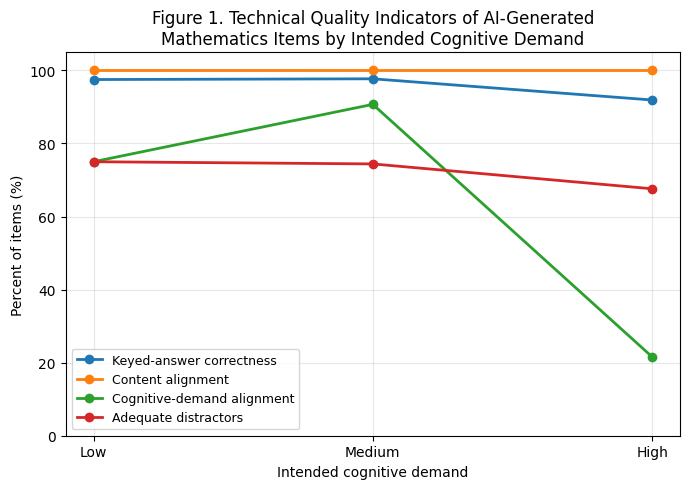

In [24]:
demand_order = ["Low", "Medium", "High"]
t1_plot = table1.set_index("Intended cognitive demand").loc[demand_order]

metrics = ["keyed_answer_correctness", "content_alignment", "cognitive_demand_alignment", "adequate_distractors"]
metric_labels = ["Keyed-answer correctness", "Content alignment", "Cognitive-demand alignment", "Adequate distractors"]

fig, ax = plt.subplots(figsize=(7, 5))
for metric, label in zip(metrics, metric_labels):
    ax.plot(demand_order, t1_plot[metric], marker="o", linewidth=2, label=label)
ax.set_xlabel("Intended cognitive demand")
ax.set_ylabel("Percent of items (%)")
ax.set_ylim(0, 105)
ax.set_title("Figure 1. Technical Quality Indicators of AI-Generated\nMathematics Items by Intended Cognitive Demand")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "figure_1_technical_quality_by_demand.png", dpi=150)
plt.show()


### Figure 2. Relative Semantic Similarity Between AI-Generated Items and Comparable Bank Items, by Cognitive-Demand Level

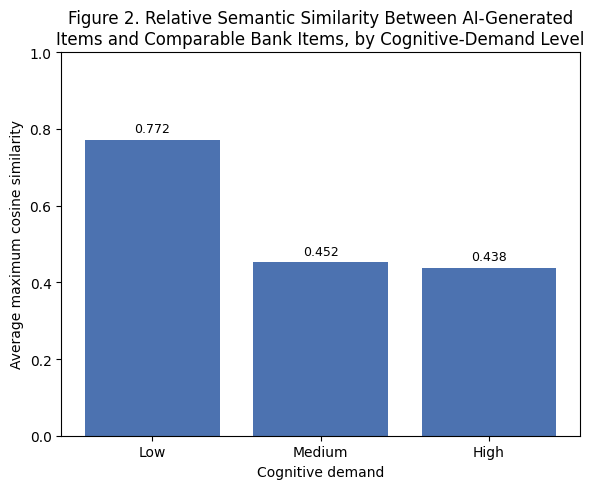

In [25]:
demand_order = ["Low", "Medium", "High"]
d1_plot = table_d1.set_index("Cognitive demand").loc[demand_order]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(demand_order, d1_plot["avg_max_cosine_similarity"], color="#4C72B0")
ax.set_xlabel("Cognitive demand")
ax.set_ylabel("Average maximum cosine similarity")
ax.set_ylim(0, 1)
ax.set_title("Figure 2. Relative Semantic Similarity Between AI-Generated\nItems and Comparable Bank Items, by Cognitive-Demand Level")
for bar, val in zip(bars, d1_plot["avg_max_cosine_similarity"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "figure_2_semantic_similarity_by_demand.png", dpi=150)
plt.show()


### Figure 3. Average Proportion of Correct Responses by Item Origin and Cognitive-Demand Level

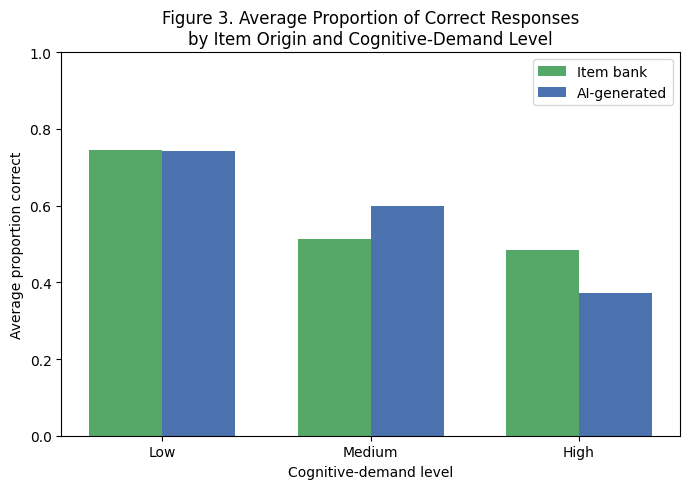

In [26]:
demand_order = ["Low", "Medium", "High"]

prop_correct = (
    long_original
    .dropna(subset=["item_correct", "origin", "cognitive_demand"])
    .groupby(["cognitive_demand", "origin"], as_index=False)["item_correct"].mean()
)
pivot = prop_correct.pivot(index="cognitive_demand", columns="origin", values="item_correct").loc[demand_order][["Bank", "AI"]]

x = np.arange(len(demand_order))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, pivot["Bank"], width, label="Item bank", color="#55A868")
ax.bar(x + width / 2, pivot["AI"], width, label="AI-generated", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(demand_order)
ax.set_xlabel("Cognitive-demand level")
ax.set_ylabel("Average proportion correct")
ax.set_ylim(0, 1)
ax.set_title("Figure 3. Average Proportion of Correct Responses\nby Item Origin and Cognitive-Demand Level")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "figure_3_proportion_correct.png", dpi=150)
plt.show()


### One-parameter IRT model (common discrimination), fit separately by test and item origin

Item difficulty and student ability are estimated with a one-parameter logistic model in which a single discrimination parameter `alpha` is shared across items within each test-form/origin block:

P(Y_ij = 1 | theta_j) = logistic(alpha * theta_j + beta_i), theta_j ~ N(0, 1)

Parameters are estimated by marginal maximum likelihood, integrating over the ability distribution with 81-point Gauss-Hermite quadrature and optimizing from several starting values for alpha to avoid local optima. A separate model is fit for the 15 AI-generated items and for the 15 bank items within each of the three test forms, six models in total.

In [27]:
from scipy.optimize import minimize
from scipy.special import expit, logsumexp
from numpy.polynomial.hermite import hermgauss

AI_ITEM_NUMS = list(range(2, 31, 2))
BANK_ITEM_NUMS = list(range(1, 31, 2))

def fit_1pl_common_discrimination(df, item_nums, n_quad=81, maxiter=5000):
    """Marginal-maximum-likelihood 1PL model with one discrimination shared across items in a block."""
    item_cols = [f"item_correct_{i}" for i in item_nums]
    X = df[item_cols].to_numpy(dtype=float)

    valid_person = ~np.all(np.isnan(X), axis=1)
    X = X[valid_person, :]
    n_persons, n_items = X.shape

    mask = ~np.isnan(X)
    X_filled = np.where(mask, X, 0)

    gh_x, gh_w = hermgauss(n_quad)
    theta_nodes = np.sqrt(2) * gh_x
    log_weights = np.log(gh_w) - 0.5 * np.log(np.pi)

    p = np.nanmean(X, axis=0)
    p = np.clip(p, 0.01, 0.99)
    beta0 = np.log(p / (1 - p))
    beta0 = np.nan_to_num(beta0, nan=0.0, posinf=4.0, neginf=-4.0)

    def negative_loglik(params):
        log_alpha = params[0]
        alpha = np.exp(log_alpha)
        beta = params[1:]

        eta = alpha * theta_nodes[:, None] + beta[None, :]
        P = expit(eta)
        logP = np.log(np.clip(P, 1e-12, 1 - 1e-12))
        log1mP = np.log(np.clip(1 - P, 1e-12, 1 - 1e-12))

        ll_nodes = X_filled @ logP.T + (1 - X_filled) @ log1mP.T
        missing = ~mask
        if missing.any():
            ll_missing = missing.astype(float) @ log1mP.T
            ll_nodes = ll_nodes - ll_missing

        person_ll = logsumexp(ll_nodes + log_weights[None, :], axis=1)
        return -np.sum(person_ll)

    start_alphas = [0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
    bounds = [(-3.0, 3.0)] + [(-8.0, 8.0)] * n_items
    results = []
    for alpha0 in start_alphas:
        init = np.r_[np.log(alpha0), beta0]
        res = minimize(negative_loglik, init, method="L-BFGS-B", bounds=bounds,
                        options={"maxiter": maxiter, "ftol": 1e-10, "gtol": 1e-6, "maxls": 80})
        results.append(res)

    best = min(results, key=lambda r: r.fun)
    alpha_hat = float(np.exp(best.x[0]))
    beta_hat = best.x[1:]
    difficulty_b = -beta_hat / alpha_hat

    params = pd.DataFrame({
        "item_num": item_nums, "item": item_cols,
        "alpha_common": alpha_hat, "beta_intercept": beta_hat, "difficulty_b": difficulty_b,
        "p_correct": np.nanmean(X, axis=0), "n_valid": np.sum(mask, axis=0),
        "n_correct": np.nansum(X, axis=0), "n_obs": n_persons,
        "converged": best.success, "neg_loglik": best.fun,
    })
    return params

def item_probability(theta_grid, alpha, beta):
    return expit(alpha * theta_grid[:, None] + beta[None, :])

def item_information(theta_grid, alpha, beta):
    P = item_probability(theta_grid, alpha, beta)
    return (alpha ** 2) * P * (1 - P)

param_list = []
for test in [1, 2, 3]:
    df_test = wide[wide["test"] == test].copy()
    for block, item_nums in {"AI": AI_ITEM_NUMS, "Item Bank": BANK_ITEM_NUMS}.items():
        params = fit_1pl_common_discrimination(df_test, item_nums)
        params["test"] = test
        params["block"] = block
        param_list.append(params)
        alpha_val = params["alpha_common"].iloc[0]
        n_obs_val = params["n_obs"].iloc[0]
        converged_val = params["converged"].iloc[0]
        print(f"Test {test}, {block}: common discrimination alpha = {alpha_val:.3f}, "
              f"n_obs = {n_obs_val}, converged = {converged_val}")

params_all = pd.concat(param_list, ignore_index=True)
params_all.to_csv(OUTPUT_TABLES / "irt_1pl_parameters_ai_itembank.csv", index=False, encoding="utf-8-sig")
display(params_all.head())


Test 1, AI: common discrimination alpha = 0.985, n_obs = 73, converged = True


Test 1, Item Bank: common discrimination alpha = 0.749, n_obs = 73, converged = True


Test 2, AI: common discrimination alpha = 0.755, n_obs = 69, converged = True


Test 2, Item Bank: common discrimination alpha = 1.144, n_obs = 69, converged = True


Test 3, AI: common discrimination alpha = 0.944, n_obs = 67, converged = True


Test 3, Item Bank: common discrimination alpha = 1.012, n_obs = 67, converged = True


,item_num,item,alpha_common,beta_intercept,difficulty_b,p_correct,n_valid,n_correct,n_obs,converged,neg_loglik,test,block
0,2,item_correct_2,0.985092,2.615717,-2.655302,0.904110,73,66.0,73,True,552.29123,1,AI
1,4,item_correct_4,0.985092,2.808208,-2.850706,0.917808,73,67.0,73,True,552.29123,1,AI
2,6,item_correct_6,0.985092,2.445434,-2.482442,0.890411,73,65.0,73,True,552.29123,1,AI
3,8,item_correct_8,0.985092,2.445434,-2.482442,0.890411,73,65.0,73,True,552.29123,1,AI
4,10,item_correct_10,0.985092,2.615717,-2.655303,0.904110,73,66.0,73,True,552.29123,1,AI


Because the model is refit here from the anonymized data, item-parameter values may differ slightly from run to run depending on which starting value the optimizer converges from; the overall shape and ordering of the curves should not.

### Figure 4. Item Characteristic Curves for AI-Generated Items Across the Three Test Forms

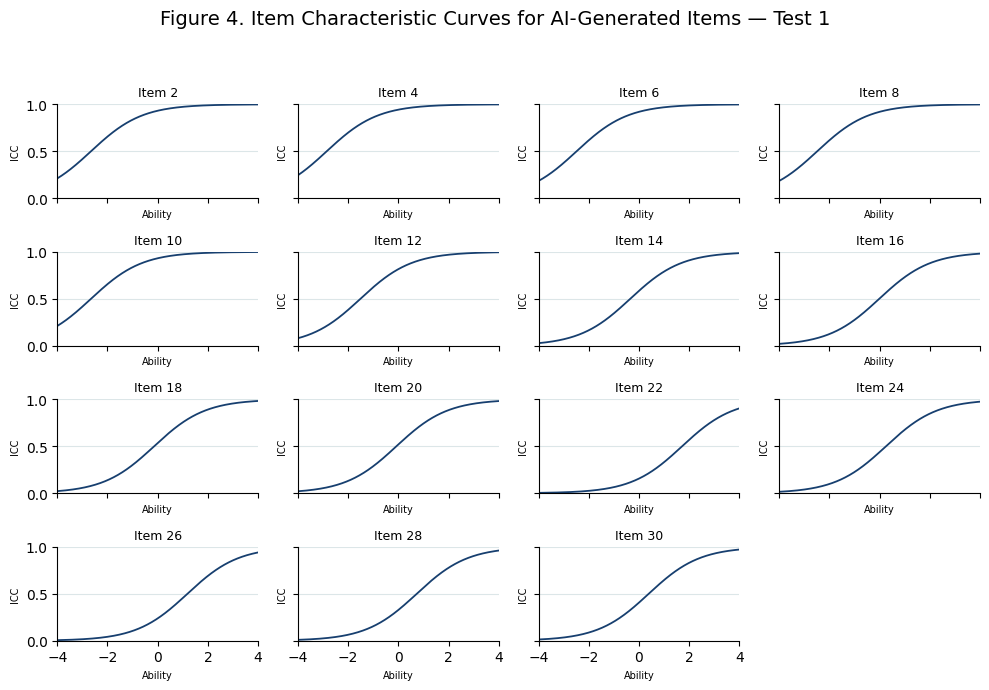

Saved: outputs/figures/figure_4_icc_test_1_ai.png


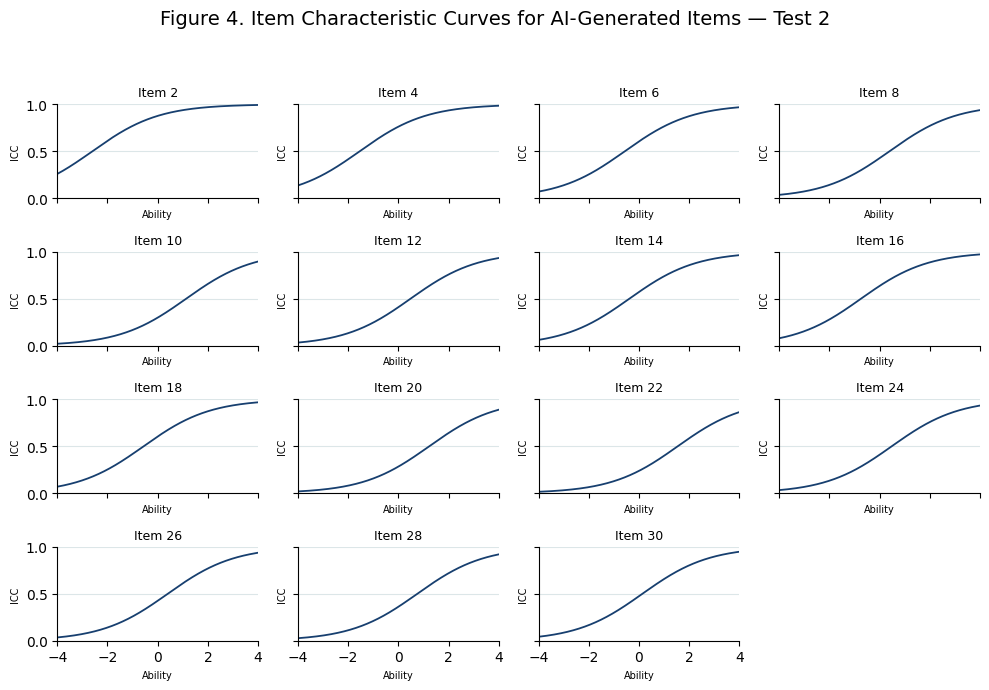

Saved: outputs/figures/figure_4_icc_test_2_ai.png


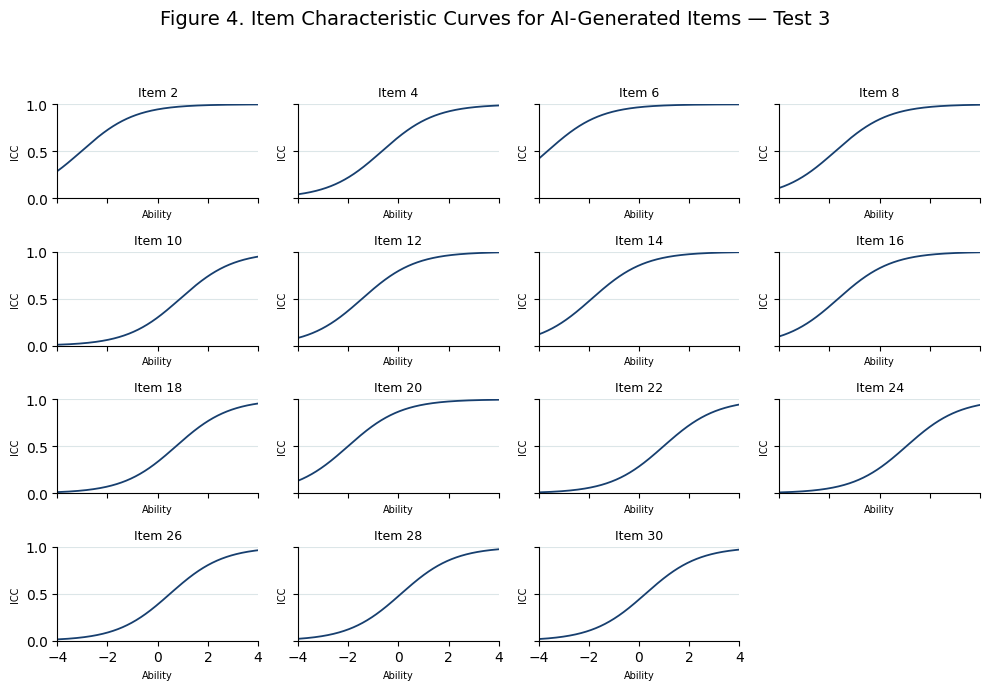

Saved: outputs/figures/figure_4_icc_test_3_ai.png


In [28]:
import math

THETA = np.linspace(-4, 4, 700)

def plot_icc_grid(params, test, block):
    params = params.sort_values("item_num").copy()
    n_items = len(params)
    ncols = 4
    nrows = math.ceil(n_items / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 7), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    alpha = params["alpha_common"].iloc[0]

    for ax_idx, ax in enumerate(axes):
        if ax_idx >= n_items:
            ax.axis("off")
            continue
        row = params.iloc[ax_idx]
        beta = row["beta_intercept"]
        prob = expit(alpha * THETA + beta)
        ax.plot(THETA, prob, color="#173f6f", linewidth=1.3)
        ax.set_title(f"Item {int(row['item_num'])}", fontsize=9)
        ax.set_xlim(-4, 4)
        ax.set_ylim(0, 1)
        ax.set_xticks([-4, -2, 0, 2, 4])
        ax.set_yticks([0, 0.5, 1.0])
        ax.grid(axis="y", color="#dce6e8", linewidth=0.8)
        ax.set_xlabel("Ability", fontsize=7)
        ax.set_ylabel("ICC", fontsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Figure 4. Item Characteristic Curves for AI-Generated Items — Test {test}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    filename = OUTPUT_FIGURES / f"figure_4_icc_test_{test}_ai.png"
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", filename)

for test in [1, 2, 3]:
    params_plot = params_all[(params_all["test"] == test) & (params_all["block"] == "AI")]
    plot_icc_grid(params_plot, test, "AI")


### Figure 5. Test Information Functions for AI-Generated and Bank Items Across the Three Tests

The test information function includes the prior information contributed by the latent-trait distribution (TIF = 1 + sum of item information, since theta is standardized to unit variance), shown together with its associated standard error curve. One figure is produced per test and item-origin combination, six in total.

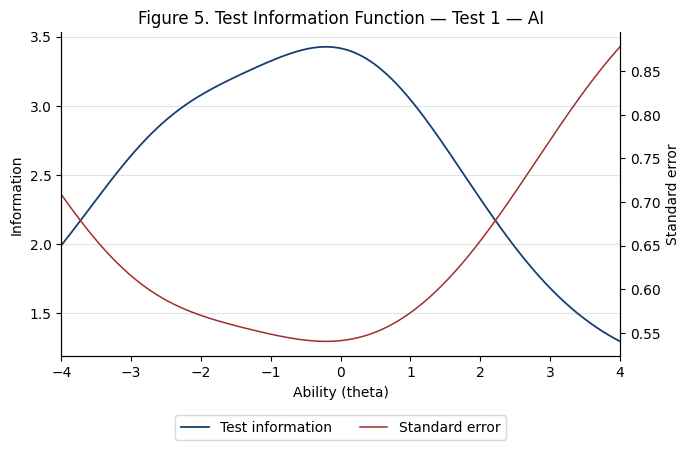

Saved: outputs/figures/figure_5_tif_test_1_ai.png


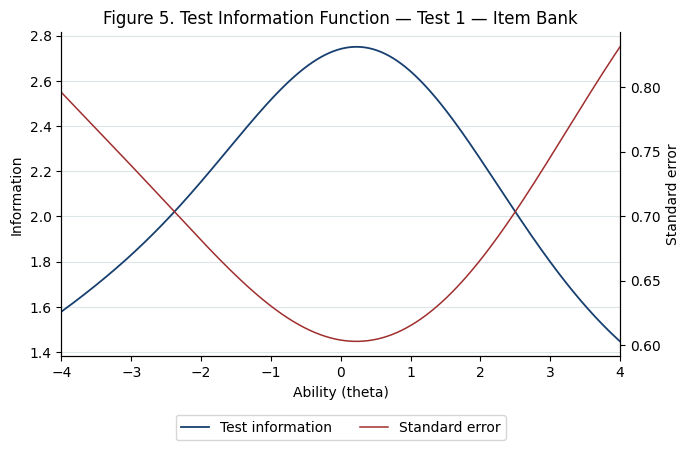

Saved: outputs/figures/figure_5_tif_test_1_item_bank.png


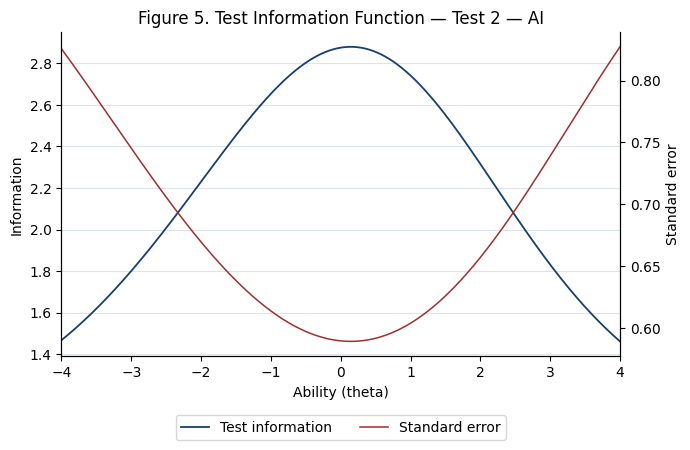

Saved: outputs/figures/figure_5_tif_test_2_ai.png


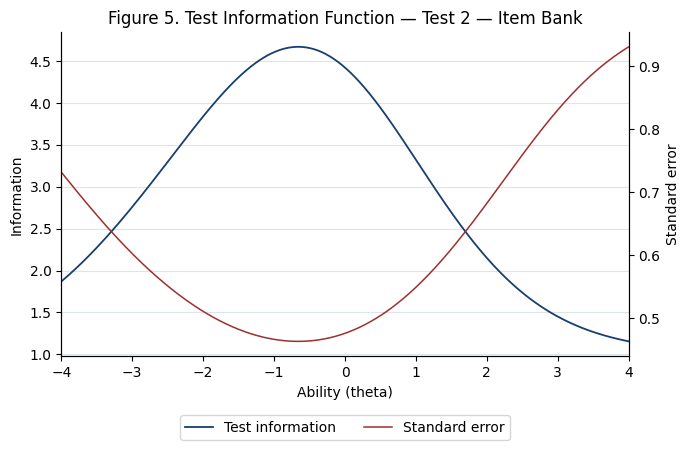

Saved: outputs/figures/figure_5_tif_test_2_item_bank.png


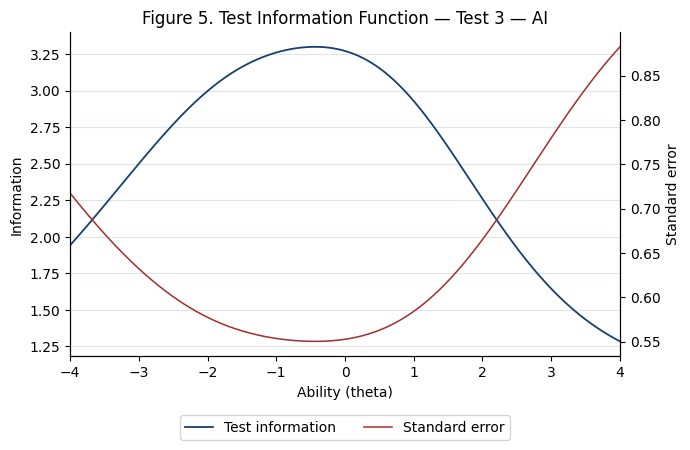

Saved: outputs/figures/figure_5_tif_test_3_ai.png


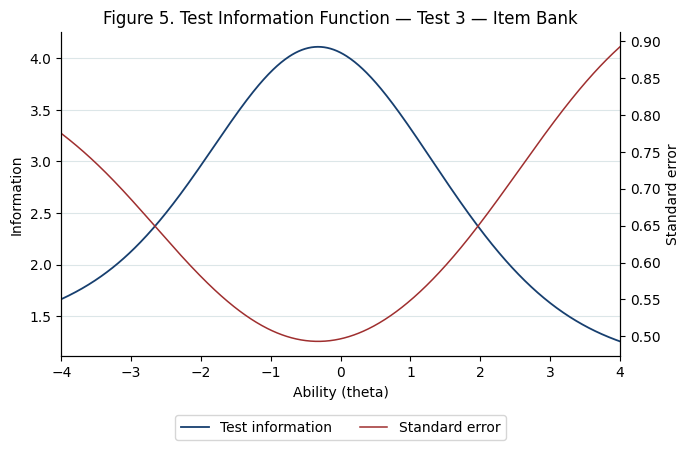

Saved: outputs/figures/figure_5_tif_test_3_item_bank.png


In [29]:
def plot_test_information(params, test, block):
    params = params.sort_values("item_num").copy()
    alpha = params["alpha_common"].iloc[0]
    beta = params["beta_intercept"].to_numpy()

    information_items = item_information(THETA, alpha, beta).sum(axis=1)
    information = 1 + information_items  # prior information from theta ~ N(0,1)
    standard_error = 1 / np.sqrt(np.maximum(information, 1e-10))

    fig, ax1 = plt.subplots(figsize=(7.0, 5.0))
    line1, = ax1.plot(THETA, information, color="#173f6f", linewidth=1.3, label="Test information")
    ax1.set_title(f"Figure 5. Test Information Function — Test {test} — {block}", fontsize=12)
    ax1.set_xlabel("Ability (theta)")
    ax1.set_ylabel("Information")
    ax1.set_xlim(-4, 4)
    ax1.grid(axis="y", color="#dce6e8", linewidth=0.8)

    ax2 = ax1.twinx()
    line2, = ax2.plot(THETA, standard_error, color="#9f2f2f", linewidth=1.1, label="Standard error")
    ax2.set_ylabel("Standard error")

    lines = [line1, line2]
    ax1.legend(lines, [l.get_label() for l in lines], loc="upper center",
               bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=True)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    fig.tight_layout(rect=[0, 0.06, 1, 1])

    safe_block = block.lower().replace(" ", "_")
    filename = OUTPUT_FIGURES / f"figure_5_tif_test_{test}_{safe_block}.png"
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", filename)
    return pd.DataFrame({"theta": THETA, "information": information, "standard_error": standard_error,
                          "test": test, "block": block, "alpha_common": alpha})

tif_outputs = []
for test in [1, 2, 3]:
    for block in ["AI", "Item Bank"]:
        params_plot = params_all[(params_all["test"] == test) & (params_all["block"] == block)]
        tif_outputs.append(plot_test_information(params_plot, test, block))

tif_all = pd.concat(tif_outputs, ignore_index=True)
tif_all.to_csv(OUTPUT_TABLES / "irt_1pl_test_information.csv", index=False, encoding="utf-8-sig")
